#### Midterm 
Design the front end of a supersonic train. In engineering terms it is often the case that you want to maximize or minimize some performance metric while staying within some set of constraints

<img src="https://github.com/DanielKim0208/ME-433RocketScience/blob/main/Midterm%20-%20supersonic%20train%20Optimization/Train%20Side%20profile.png?raw=true" width="50%">



#### Strategy 

The total cost(point of optimization) is given by 

$C = 20 \times N \times D$
where 

1. C is optimization point COST
2. N is the number of trips N
3. D is the Drag in newtons 


$N = 2\left\lceil \frac{1}{V} \right\rceil - 1, \qquad 0 < V \le 1$



### Approach Strategy 

1. I will define the dotted line box to have 1 by 1 dimensions. 
<br>

https://www.101computing.net/the-shoelace-algorithm/ <br>

2. I will make a function that takes in the number of vertice and linmaps out the possible vertice coordinates in the region

<br>

4. For the inviscid assumption, I will make a function that calculates the drag given the vertice locations 
5. For the viscocious assumption, [Ask in office hours on this approach]
<br>

6. I will use the two functions for multidomain optimization wtih scipy or pytorch(Look into documentation)
7. I will optimize and find the best possible solutions. 
<br>



Assumptions 

1. Conditions : <br>
    M = 3 <br>
    T = 300K <br>
    P = 101325 <br>
    L = 1m  
2. Analysis using the oblique shocks and expansion waves only 
3. Only care about the overall drag in the X direction
4. . This is my assumption. There's no way $\Sigma$ shaped train is better than 'bullet' shaped train. I'll work on its implementation but this is a rule that can minimax filter a lot of cases
5. In the given plane closed by the dotted line, the bottom left is (0,0). The top right is (1,1)

0 (np.float64(0.0), np.float64(0.0)) 0.5
1 (np.float64(0.010101010101010102), np.float64(0.0)) 0.495
2 (np.float64(0.020202020202020204), np.float64(0.0)) 0.49
3 (np.float64(0.030303030303030304), np.float64(0.0)) 0.485
4 (np.float64(0.04040404040404041), np.float64(0.0)) 0.48
5 (np.float64(0.05050505050505051), np.float64(0.0)) 0.475
6 (np.float64(0.06060606060606061), np.float64(0.0)) 0.47
7 (np.float64(0.07070707070707072), np.float64(0.0)) 0.465
8 (np.float64(0.08080808080808081), np.float64(0.0)) 0.46
9 (np.float64(0.09090909090909091), np.float64(0.0)) 0.455
10 (np.float64(0.10101010101010102), np.float64(0.0)) 0.449
11 (np.float64(0.11111111111111112), np.float64(0.0)) 0.444
12 (np.float64(0.12121212121212122), np.float64(0.0)) 0.439
13 (np.float64(0.13131313131313133), np.float64(0.0)) 0.434
14 (np.float64(0.14141414141414144), np.float64(0.0)) 0.429
15 (np.float64(0.15151515151515152), np.float64(0.0)) 0.424
16 (np.float64(0.16161616161616163), np.float64(0.0)) 0.419
17 (np.fl

C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\897503649.py:32: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate("A", A, textcoords="offset points",  fontsize=12)
C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\897503649.py:33: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate("B", B, textcoords="offset points",fontsize=12)
C:\Users\tanka\AppData\Local\Temp\ipykernel_8464\897503649.py:34: UserWarning: You have used the `textcoords` kwarg, but not the `xytext` kwarg.  This can lead to surprising results.
  ax.annotate(f"P:{k}", pts[k], textcoords="offset points",  fontsize=12)


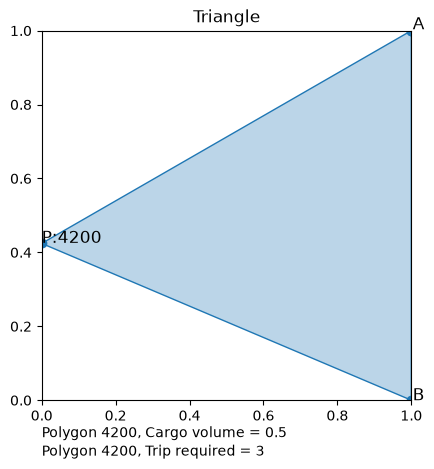

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import shapely.geometry as geo
import shapely.plotting as shplt
import math

A, B = (1, 1), (1, 0) 
n = 100  # axis grid count, n*n polygons

pts = [(x, y) for y in np.linspace(0, 1, n) for x in np.linspace(0, 1, n)]
polygons = [geo.Polygon([A, B, p]) for p in pts]

# Numbered list: pick one from here
for i in range(len(polygons)):
    print(i, pts[i], round(polygons[i].area, 3))

#The function Calculates the N, the required trip number, according to the polygon geometry
#The trip number is always odd : If you moved cargo the way from NYC to SF, just stay there 
#The trip number always rounds up. You need to move ALL the cargo

def Tripnumber(polygon): 
    deliveries = math.ceil(round(1 / polygon.area, 9))
    return 2 * deliveries - 1


# Plotting function to plot the given triangle using the shapely.plotting library
def plot_polygon(k):

    fig, ax = plt.subplots()
    shplt.plot_polygon(polygons[k], ax=ax, add_points=True)

    ax.annotate("A", A, textcoords="offset points",  fontsize=12)
    ax.annotate("B", B, textcoords="offset points",fontsize=12)
    ax.annotate(f"P:{k}", pts[k], textcoords="offset points",  fontsize=12)


    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")

    ax.set_title("Triangle")

    plt.text(0,-0.1, f"Polygon {k}, Cargo volume = {round(polygons[k].area, 3)}")
    plt.text(0,-0.15, f"Polygon {k}, Trip required = {Tripnumber(polygons[k])}")
    plt.show()

plot_polygon(4200)